<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Block 1
from google.colab import drive
drive.mount('/content/drive')

import os, time, csv
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("CUDA available:", torch.cuda.is_available())

Mounted at /content/drive
CUDA available: True


In [2]:
# Block 2
print("Raw dataset present:", os.path.exists('/content/data/Dataset_BUSI_with_GT'))

Raw dataset present: False


In [3]:
from google.colab import userdata
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
os.makedirs("/content/data", exist_ok=True)
!pip install -q -U kaggle
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p /content/data --unzip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.7 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:10<00:00, 20.0MB/s]



In [4]:
import os
print(os.path.exists('/content/drive/MyDrive/BUSI_Dataset/splits'))
print(os.listdir('/content/drive/MyDrive/BUSI_Dataset'))

False
['Dataset_BUSI_with_GT', 'tier1_attention_unet', 'test.csv', 'train.csv', 'val.csv']


In [5]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/BUSI_Dataset/train.csv')
print(df.columns.tolist())
print(df.head())

['class', 'image_path', 'mask_paths']
       class                                         image_path  \
0  malignant  /content/data/Dataset_BUSI_with_GT/malignant/m...   
1     benign  /content/data/Dataset_BUSI_with_GT/benign/beni...   
2  malignant  /content/data/Dataset_BUSI_with_GT/malignant/m...   
3     benign  /content/data/Dataset_BUSI_with_GT/benign/beni...   
4  malignant  /content/data/Dataset_BUSI_with_GT/malignant/m...   

                                          mask_paths  
0  /content/data/Dataset_BUSI_with_GT/malignant/m...  
1  /content/data/Dataset_BUSI_with_GT/benign/beni...  
2  /content/data/Dataset_BUSI_with_GT/malignant/m...  
3  /content/data/Dataset_BUSI_with_GT/benign/beni...  
4  /content/data/Dataset_BUSI_with_GT/malignant/m...  


In [6]:
import glob
for path in glob.glob('/content/drive/MyDrive/**/train.csv', recursive=True):
    try:
        cols = pd.read_csv(path, nrows=1).columns.tolist()
        rows = sum(1 for _ in open(path)) - 1
        print(f"{path}\n  columns: {cols}\n  rows: {rows}\n")
    except Exception as e:
        print(f"{path} -> error reading: {e}")

/content/drive/MyDrive/BUSI_Dataset/train.csv
  columns: ['class', 'image_path', 'mask_paths']
  rows: 368



In [7]:
!pip install -q ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.2 MB/s eta 0:00:00


In [8]:
import os, hashlib, random, csv
from collections import defaultdict
from itertools import combinations
from PIL import Image
import imagehash  # if this errors: !pip install -q ImageHash

random.seed(42)

ROOT = '/content/data/Dataset_BUSI_with_GT'
CLASSES = ['benign', 'malignant']
NEAR_DUP_THRESHOLD = 5

print("Raw dataset present:", os.path.exists(ROOT))  # must be True before continuing

def collect_images(root, classes):
    records = []
    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)
        images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg')) and '_mask' not in f.lower()]
        for image_file in images:
            base_name = os.path.splitext(image_file)[0]
            masks = [f for f in all_files if f.startswith(base_name + '_mask')]
            records.append({
                'class': cls, 'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [os.path.join(folder, m) for m in masks],
            })
    return records

def md5_hash(filepath):
    md5 = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)
    return md5.hexdigest()

def phash(filepath):
    return imagehash.phash(Image.open(filepath).convert('L'))

def find_exact_duplicate_groups(records):
    groups = defaultdict(list)
    for r in records:
        groups[md5_hash(r['image_path'])].append(r)
    return [g for g in groups.values() if len(g) > 1]

def find_near_duplicate_pairs(records, threshold):
    hashes = [(r, phash(r['image_path'])) for r in records]
    pairs = []
    for (r_a, h_a), (r_b, h_b) in combinations(hashes, 2):
        if h_a - h_b <= threshold:
            pairs.append((r_a, r_b, h_a - h_b))
    return pairs

class UnionFind:
    def __init__(self, items):
        self.parent = {id(item): item for item in items}
    def find(self, item):
        pid = id(item)
        while self.parent[pid] is not item:
            item = self.parent[pid]; pid = id(item)
        return item
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra is not rb:
            self.parent[id(ra)] = rb

def group_near_duplicates(records, pairs):
    uf = UnionFind(records)
    for r_a, r_b, _ in pairs:
        uf.union(r_a, r_b)
    groups = defaultdict(list)
    for r in records:
        groups[id(uf.find(r))].append(r)
    return [g for g in groups.values() if len(g) > 1]

def stratified_split(records, classes, ratios=(0.70, 0.15, 0.15)):
    train, val, test = [], [], []
    for cls in classes:
        cls_records = [r for r in records if r['class'] == cls]
        random.shuffle(cls_records)
        n = len(cls_records)
        n_train, n_val = int(n * ratios[0]), int(n * ratios[1])
        train.extend(cls_records[:n_train])
        val.extend(cls_records[n_train:n_train + n_val])
        test.extend(cls_records[n_train + n_val:])
    random.shuffle(train); random.shuffle(val); random.shuffle(test)
    return train, val, test

def save_split_csv(path, records):
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['class', 'image_path', 'mask_paths'])
        for r in records:
            writer.writerow([r['class'], r['image_path'], '|'.join(r['mask_paths'])])

print("Collecting image records...")
records = collect_images(ROOT, CLASSES)
print(f"Total benign+malignant images: {len(records)}")

exact_groups = find_exact_duplicate_groups(records)
print(f"Exact duplicate groups: {len(exact_groups)}")

near_pairs = find_near_duplicate_pairs(records, NEAR_DUP_THRESHOLD)
near_groups = group_near_duplicates(records, near_pairs)
print(f"Near-duplicate groups: {len(near_groups)}")

same_class_groups, cross_class_groups = [], []
for g in near_groups:
    (cross_class_groups if len({r['class'] for r in g}) > 1 else same_class_groups).append(g)
print(f"Same-class groups: {len(same_class_groups)} | Cross-class conflict groups: {len(cross_class_groups)}")

excluded_paths = {r['image_path'] for g in cross_class_groups for r in g}
kept_records, seen_paths = [], set()
for g in same_class_groups:
    kept_records.append(g[0]); seen_paths.add(g[0]['image_path'])
    for r in g[1:]:
        seen_paths.add(r['image_path'])
for r in records:
    if r['image_path'] not in excluded_paths and r['image_path'] not in seen_paths:
        kept_records.append(r)

print(f"Final deduplicated dataset: {len(kept_records)} images (removed {len(records)-len(kept_records)})")

train, val, test = stratified_split(kept_records, CLASSES)
print(f"Split — train: {len(train)}, val: {len(val)}, test: {len(test)}")

FINAL_DIR = '/content/drive/MyDrive/BUSI_Dataset'
save_split_csv(f'{FINAL_DIR}/train.csv', train)
save_split_csv(f'{FINAL_DIR}/val.csv', val)
save_split_csv(f'{FINAL_DIR}/test.csv', test)
print("Saved to Drive.")

check = pd.read_csv(f'{FINAL_DIR}/train.csv') if 'pd' in dir() else __import__('pandas').read_csv(f'{FINAL_DIR}/train.csv')
print("Verification — columns:", check.columns.tolist(), "| rows:", len(check))

Raw dataset present: True
Total benign+malignant images: 647
Exact duplicate groups: 1
Near-duplicate groups: 98
Same-class groups: 92 | Cross-class conflict groups: 6
Final deduplicated dataset: 527 images (removed 120)
Split — train: 368, val: 78, test: 81
Saved to Drive.
Verification — columns: ['class', 'image_path', 'mask_paths'] | rows: 368


In [15]:
train_loader, val_loader, test_loader = get_dataloaders('/content/drive/MyDrive/BUSI_Dataset')

Train: 368 | Val: 78 | Test: 81


In [10]:
IMG_SIZE = 256

def get_train_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_eval_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class BUSISegmentationDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.records = []
        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                mask_paths = row['mask_paths'].split('|') if row['mask_paths'] else []
                self.records.append({'class': row['class'], 'image_path': row['image_path'], 'mask_paths': mask_paths})
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image = np.array(Image.open(record['image_path']).convert('RGB'))
        mask = None
        for mp in record['mask_paths']:
            m = (np.array(Image.open(mp).convert('L')) > 0).astype(np.uint8)
            mask = m if mask is None else np.maximum(mask, m)
        if mask is None:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask'].unsqueeze(0).float()
        return {'image': image, 'mask': mask, 'class': record['class']}

def get_dataloaders(splits_dir, batch_size=16, img_size=IMG_SIZE, num_workers=2):
    train_ds = BUSISegmentationDataset(f'{splits_dir}/train.csv', transform=get_train_transform(img_size))
    val_ds = BUSISegmentationDataset(f'{splits_dir}/val.csv', transform=get_eval_transform(img_size))
    test_ds = BUSISegmentationDataset(f'{splits_dir}/test.csv', transform=get_eval_transform(img_size))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders('/content/drive/MyDrive/BUSI_Dataset')

batch = next(iter(train_loader))
print("Image shape:", batch["image"].shape, "| Mask shape:", batch["mask"].shape)

Train: 368 | Val: 78 | Test: 81
Image shape: torch.Size([16, 3, 256, 256]) | Mask shape: torch.Size([16, 1, 256, 256])


In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

class AttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.enc1 = ConvBlock(in_ch, features[0]); self.enc2 = ConvBlock(features[0], features[1])
        self.enc3 = ConvBlock(features[1], features[2]); self.enc4 = ConvBlock(features[2], features[3])
        self.bottleneck = ConvBlock(features[3], features[3]*2)
        self.up4 = nn.ConvTranspose2d(features[3]*2, features[3], 2, stride=2)
        self.att4 = AttentionGate(features[3], features[3], features[3]//2); self.dec4 = ConvBlock(features[3]*2, features[3])
        self.up3 = nn.ConvTranspose2d(features[3], features[2], 2, stride=2)
        self.att3 = AttentionGate(features[2], features[2], features[2]//2); self.dec3 = ConvBlock(features[2]*2, features[2])
        self.up2 = nn.ConvTranspose2d(features[2], features[1], 2, stride=2)
        self.att2 = AttentionGate(features[1], features[1], features[1]//2); self.dec2 = ConvBlock(features[1]*2, features[1])
        self.up1 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)
        self.att1 = AttentionGate(features[0], features[0], features[0]//2); self.dec1 = ConvBlock(features[0]*2, features[0])
        self.final = nn.Conv2d(features[0], out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b); d4 = self.dec4(torch.cat([d4, self.att4(g=d4, x=e4)], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, self.att3(g=d3, x=e3)], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, self.att2(g=d2, x=e2)], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, self.att1(g=d1, x=e1)], dim=1))
        return self.final(d1)

print("Model defined")

Model defined


In [13]:
def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_metrics = 0, []
    with torch.no_grad():
        for batch in loader:
            images, masks = batch["image"].to(device), batch["mask"].to(device)
            preds = model(images)
            total_loss += loss_fn(preds, masks).item()
            all_metrics.append(compute_metrics(preds, masks))
    avg = {k: sum(m[k] for m in all_metrics)/len(all_metrics) for k in all_metrics[0]}
    return total_loss / len(loader), avg

print("validate() defined")

validate() defined


In [16]:
test_loss, test_metrics = validate(model, test_loader, loss_fn, device)
print("Test set results:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

NameError: name 'model' is not defined

In [17]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, pred_logits, target):
        bce_loss = self.bce(pred_logits, target)
        pred = torch.sigmoid(pred_logits)
        pf, tf = pred.view(-1), target.view(-1)
        intersection = (pf * tf).sum()
        dice_loss = 1 - (2*intersection + self.smooth) / (pf.sum() + tf.sum() + self.smooth)
        return bce_loss + dice_loss

def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum(); fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum(); tn = ((1 - pred) * (1 - target)).sum()
    dice = (2*tp + 1e-6) / (2*tp + fp + fn + 1e-6)
    iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    specificity = (tn + 1e-6) / (tn + fp + 1e-6)
    return {"dice": dice.item(), "iou": iou.item(), "precision": precision.item(), "recall": recall.item(), "specificity": specificity.item()}

print("Loss and metrics defined")

Loss and metrics defined


In [17]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train(); total_loss = 0
    for batch in loader:
        images, masks = batch["image"].to(device), batch["mask"].to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, masks)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, loss_fn, device):
    model.eval(); total_loss, all_metrics = 0, []
    with torch.no_grad():
        for batch in loader:
            images, masks = batch["image"].to(device), batch["mask"].to(device)
            preds = model(images)
            total_loss += loss_fn(preds, masks).item()
            all_metrics.append(compute_metrics(preds, masks))
    avg = {k: sum(m[k] for m in all_metrics)/len(all_metrics) for k in all_metrics[0]}
    return total_loss / len(loader), avg

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)  # must say cuda

model = AttentionUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = DiceBCELoss()

PROJECT_DIR = '/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet'
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/logs', exist_ok=True)

NUM_EPOCHS, PATIENCE = 50, 10
best_val_dice, epochs_no_improve = 0.0, 0
checkpoint_path = f'{PROJECT_DIR}/checkpoints/attention_unet_best.pth'
history = []

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_metrics = validate(model, val_loader, loss_fn, device)
    history.append({'epoch': epoch+1, 'train_loss': train_loss, 'val_loss': val_loss, **val_metrics})
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_dice: {val_metrics['dice']:.4f} | val_iou: {val_metrics['iou']:.4f} | {time.time()-start:.1f}s")
    if val_metrics['dice'] > best_val_dice:
        best_val_dice, epochs_no_improve = val_metrics['dice'], 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  -> new best, saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}"); break

pd.DataFrame(history).to_csv(f'{PROJECT_DIR}/logs/training_history.csv', index=False)
print(f"\nTraining complete. Best val Dice: {best_val_dice:.4f}")

Using device: cuda
Epoch 1/50 | train_loss: 1.4605 | val_loss: 1.4391 | val_dice: 0.0014 | val_iou: 0.0007 | 23.4s
  -> new best, saved
Epoch 2/50 | train_loss: 1.3240 | val_loss: 1.3515 | val_dice: 0.1373 | val_iou: 0.0755 | 21.9s
  -> new best, saved
Epoch 3/50 | train_loss: 1.2858 | val_loss: 1.2685 | val_dice: 0.2017 | val_iou: 0.1141 | 22.4s
  -> new best, saved
Epoch 4/50 | train_loss: 1.2227 | val_loss: 1.4080 | val_dice: 0.3664 | val_iou: 0.2247 | 22.6s
  -> new best, saved
Epoch 5/50 | train_loss: 1.1533 | val_loss: 1.1212 | val_dice: 0.5464 | val_iou: 0.3762 | 22.9s
  -> new best, saved
Epoch 6/50 | train_loss: 1.0980 | val_loss: 1.1123 | val_dice: 0.5387 | val_iou: 0.3694 | 23.7s
Epoch 7/50 | train_loss: 1.0627 | val_loss: 1.1049 | val_dice: 0.5807 | val_iou: 0.4094 | 24.1s
  -> new best, saved
Epoch 8/50 | train_loss: 1.0293 | val_loss: 1.0433 | val_dice: 0.6225 | val_iou: 0.4519 | 23.3s
  -> new best, saved
Epoch 9/50 | train_loss: 0.9969 | val_loss: 1.0130 | val_dice: 0.6

In [1]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

test_loss, test_metrics = validate(model, test_loader, loss_fn, device)
print("Test set results:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

NameError: name 'model' is not defined

In [18]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

class AttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.enc1 = ConvBlock(in_ch, features[0]); self.enc2 = ConvBlock(features[0], features[1])
        self.enc3 = ConvBlock(features[1], features[2]); self.enc4 = ConvBlock(features[2], features[3])
        self.bottleneck = ConvBlock(features[3], features[3]*2)
        self.up4 = nn.ConvTranspose2d(features[3]*2, features[3], 2, stride=2)
        self.att4 = AttentionGate(features[3], features[3], features[3]//2); self.dec4 = ConvBlock(features[3]*2, features[3])
        self.up3 = nn.ConvTranspose2d(features[3], features[2], 2, stride=2)
        self.att3 = AttentionGate(features[2], features[2], features[2]//2); self.dec3 = ConvBlock(features[2]*2, features[2])
        self.up2 = nn.ConvTranspose2d(features[2], features[1], 2, stride=2)
        self.att2 = AttentionGate(features[1], features[1], features[1]//2); self.dec2 = ConvBlock(features[1]*2, features[1])
        self.up1 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)
        self.att1 = AttentionGate(features[0], features[0], features[0]//2); self.dec1 = ConvBlock(features[0]*2, features[0])
        self.final = nn.Conv2d(features[0], out_ch, kernel_size=1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b); d4 = self.dec4(torch.cat([d4, self.att4(g=d4, x=e4)], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, self.att3(g=d3, x=e3)], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, self.att2(g=d2, x=e2)], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, self.att1(g=d1, x=e1)], dim=1))
        return self.final(d1)

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, pred_logits, target):
        bce_loss = self.bce(pred_logits, target)
        pred = torch.sigmoid(pred_logits)
        pf, tf = pred.view(-1), target.view(-1)
        intersection = (pf * tf).sum()
        dice_loss = 1 - (2*intersection + self.smooth) / (pf.sum() + tf.sum() + self.smooth)
        return bce_loss + dice_loss

def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum(); fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum(); tn = ((1 - pred) * (1 - target)).sum()
    dice = (2*tp + 1e-6) / (2*tp + fp + fn + 1e-6)
    iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    specificity = (tn + 1e-6) / (tn + fp + 1e-6)
    return {"dice": dice.item(), "iou": iou.item(), "precision": precision.item(), "recall": recall.item(), "specificity": specificity.item()}

def validate(model, loader, loss_fn, device):
    model.eval(); total_loss, all_metrics = 0, []
    with torch.no_grad():
        for batch in loader:
            images, masks = batch["image"].to(device), batch["mask"].to(device)
            preds = model(images)
            total_loss += loss_fn(preds, masks).item()
            all_metrics.append(compute_metrics(preds, masks))
    avg = {k: sum(m[k] for m in all_metrics)/len(all_metrics) for k in all_metrics[0]}
    return total_loss / len(loader), avg

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

model = AttentionUNet().to(device)
loss_fn = DiceBCELoss()

checkpoint_path = '/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/checkpoints/attention_unet_best.pth'
print("Checkpoint exists:", os.path.exists(checkpoint_path))

model.load_state_dict(torch.load(checkpoint_path))
model.eval()
print("Model built and checkpoint loaded successfully")

Device: cuda
Checkpoint exists: True
Model built and checkpoint loaded successfully


In [19]:
test_loss, test_metrics = validate(model, test_loader, loss_fn, device)
print("Test set results:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

Test set results:
  dice: 0.7215
  iou: 0.5698
  precision: 0.7999
  recall: 0.6629
  specificity: 0.9780


In [20]:
print("model exists:", 'model' in dir())
print("validate exists:", 'validate' in dir())
print("device exists:", 'device' in dir())

model exists: True
validate exists: True
device exists: True


In [21]:
results_summary = {
    'model': 'Attention U-Net (Tier 1)',
    'dataset': 'BUSI (527 images, deduplicated, 70/15/15 split)',
    **test_metrics
}

import json
results_path = '/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/logs/test_results.json'
with open(results_path, 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Saved:", results_path)

Saved: /content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/logs/test_results.json


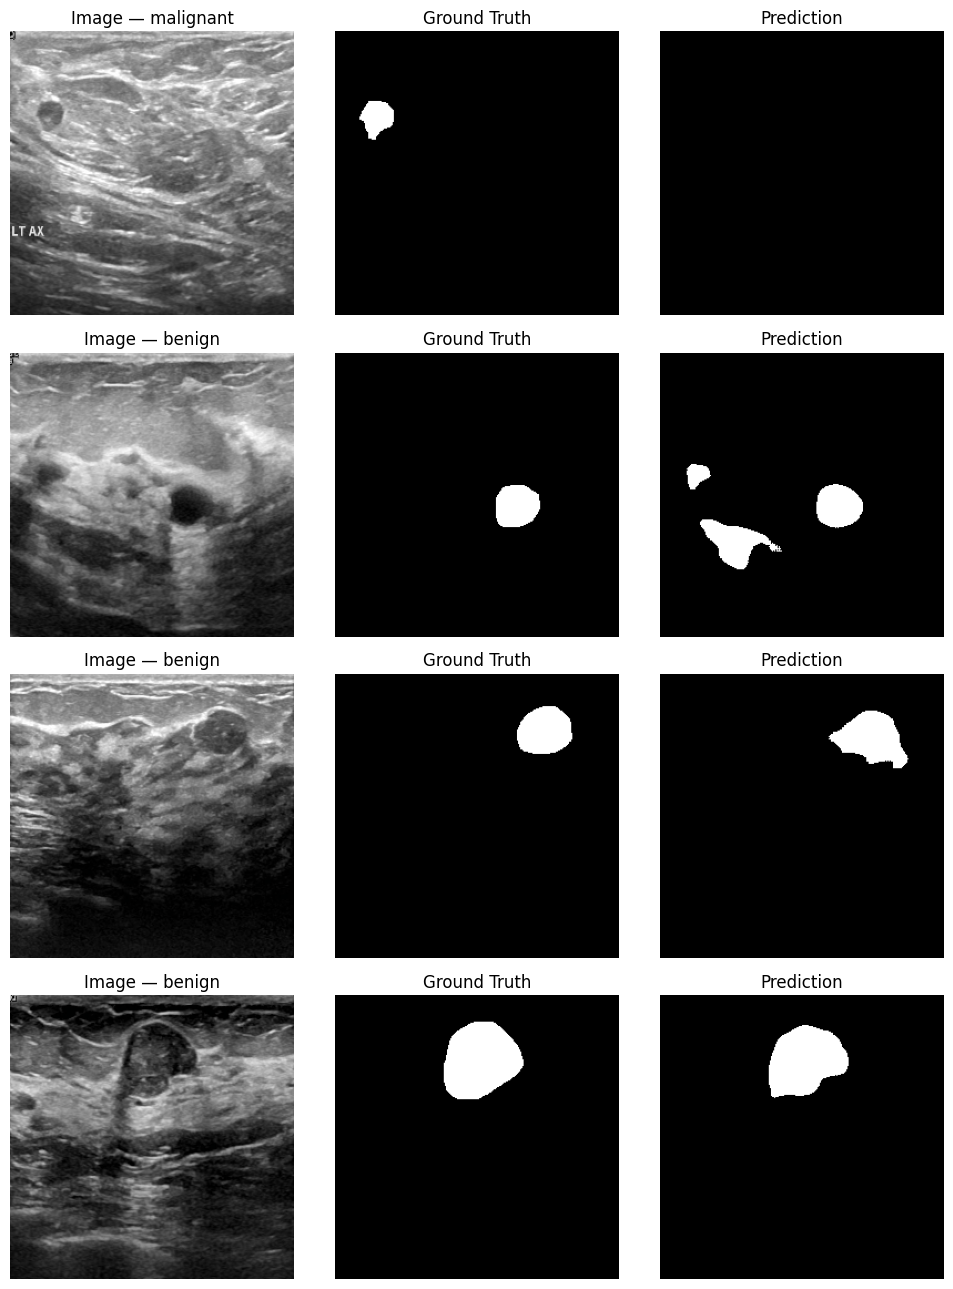

In [22]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()
batch = next(iter(test_loader))
images, masks = batch["image"].to(device), batch["mask"].to(device)
with torch.no_grad():
    preds = torch.sigmoid(model(images)) > 0.5

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
for i in range(4):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Image — {batch['class'][i]}"); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt, cmap='gray'); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title("Prediction"); axes[i, 2].axis('off')
plt.tight_layout()
plt.show()